In [28]:
# ============================================================
# NOTEBOOK 04 — NLP Analysis
# Sentiment Analysis (VADER) + Topic Modelling (sklearn LDA)
# ============================================================

# ── CELL 1: Path Setup & Imports ─────────────────────────────────────────────
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

# Resolve project root (works from notebooks/ subfolder or project root)
_cwd = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, '..')) \
               if not os.path.exists(os.path.join(_cwd, 'Data')) else _cwd

DATA_DIR   = os.path.join(PROJECT_ROOT, 'Data')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}   {'✅' if os.path.exists(DATA_DIR) else '❌'}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR} ✅")


PROJECT_ROOT : C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike
DATA_DIR     : C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\Data   ✅
OUTPUT_DIR   : C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\outputs ✅


In [29]:
# ── CELL 2: Import NLP utils ─────────────────────────────────────────────────
from Utils.nlp_utils import (
    clean_text_basic,
    clean_text_for_nlp,
    clean_texts_for_vectorizer,
    apply_sentiment,
    get_sentiment_summary,
    sentiment_by_group,
    build_lda_model,
    get_topic_labels,
    get_dominant_topic,
    assign_topics_to_df,
    find_optimal_num_topics,
    compute_tfidf_top_terms,
    tfidf_by_sentiment,
    plot_sentiment_distribution,
    plot_sentiment_over_time,
    plot_topic_perplexity,
    plot_topic_top_words,
    plot_topic_sentiment_heatmap,
    plot_wordcloud_per_topic,
    FUEL_DOMAIN_STOPWORDS,
)
print("✅ NLP utils imported successfully")



✅ NLP utils imported successfully


In [30]:
# ── CELL 3: Load Data ─────────────────────────────────────────────────────────
comments_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_processed.csv'))
videos_df   = pd.read_csv(os.path.join(DATA_DIR, 'videos_processed.csv'))

print(f"Comments loaded : {len(comments_df)} rows")
print(f"Videos loaded   : {len(videos_df)} rows")
print(f"\nComments columns: {comments_df.columns.tolist()}")

# Ensure text column exists — detect it automatically
TEXT_COL_CANDIDATES = ['text', 'textDisplay', 'text_display', 'comment_text', 'body']
TEXT_COL = None
for col in TEXT_COL_CANDIDATES:
    if col in comments_df.columns:
        TEXT_COL = col
        print(f"\n✅ Using text column: '{TEXT_COL}'")
        break

if TEXT_COL is None:
    print("❌ No text column found. Available:", comments_df.columns.tolist())
    raise ValueError("Cannot proceed without a text column.")

# Drop rows with missing text
comments_df = comments_df.dropna(subset=[TEXT_COL]).reset_index(drop=True)
print(f"Rows after dropping null text: {len(comments_df)}")



Comments loaded : 11398 rows
Videos loaded   : 212 rows

Comments columns: ['comment_id', 'video_id', 'author_id', 'author_name', 'text', 'like_count', 'reply_count', 'published_at', 'updated_at', 'year_month', 'day_of_week', 'hour', 'is_english']

✅ Using text column: 'text'
Rows after dropping null text: 11398


In [31]:
# ── CELL 4: Basic Text Cleaning ───────────────────────────────────────────────
# Apply light cleaning — preserve punctuation for VADER
comments_df['text_clean'] = comments_df[TEXT_COL].apply(clean_text_basic)

print("Sample cleaned texts:")
for i, row in comments_df.head(3).iterrows():
    print(f"\n  Original : {str(row[TEXT_COL])[:120]}")
    print(f"  Cleaned  : {str(row['text_clean'])[:120]}")



Sample cleaned texts:

  Original : Luto Bengal ko
  Cleaned  : luto bengal ko

  Original : Bhai ese hi sach bolna ….. proud hai apke uppar
  Cleaned  : bhai ese hi sach bolna .. proud hai apke uppar

  Original : Waah waah isey kehte hain guts ..sach bolne ke liye balls honi chahiye jo aap mein hai
  Cleaned  : waah waah isey kehte hain guts ..sach bolne ke liye balls honi chahiye jo aap mein hai


In [32]:
# ============================================================
# SECTION A — SENTIMENT ANALYSIS (VADER)
# ============================================================

# ── CELL 5: Apply VADER Sentiment ─────────────────────────────────────────────
# VADER is chosen because:
#   - Designed specifically for social media short text
#   - Handles slang, capitalisation, punctuation emphasis
#   - No training data required
#   - Compound score: >= 0.05 Positive, <= -0.05 Negative, else Neutral

comments_df = apply_sentiment(comments_df, text_col='text_clean')

print("Sentiment columns added:", ['compound', 'label', 'pos', 'neg', 'neu'])
print("\nSentiment Distribution:")
summary = get_sentiment_summary(comments_df)
print(summary.to_string(index=False))

17:41:35 [INFO] Applying VADER to 11398 rows...


Sentiment columns added: ['compound', 'label', 'pos', 'neg', 'neu']

Sentiment Distribution:
   label  count  percentage
 Neutral   4593        40.3
Positive   3518        30.9
Negative   3287        28.8


17:41:36 [INFO] Saved: C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\outputs\05_sentiment_distribution.png


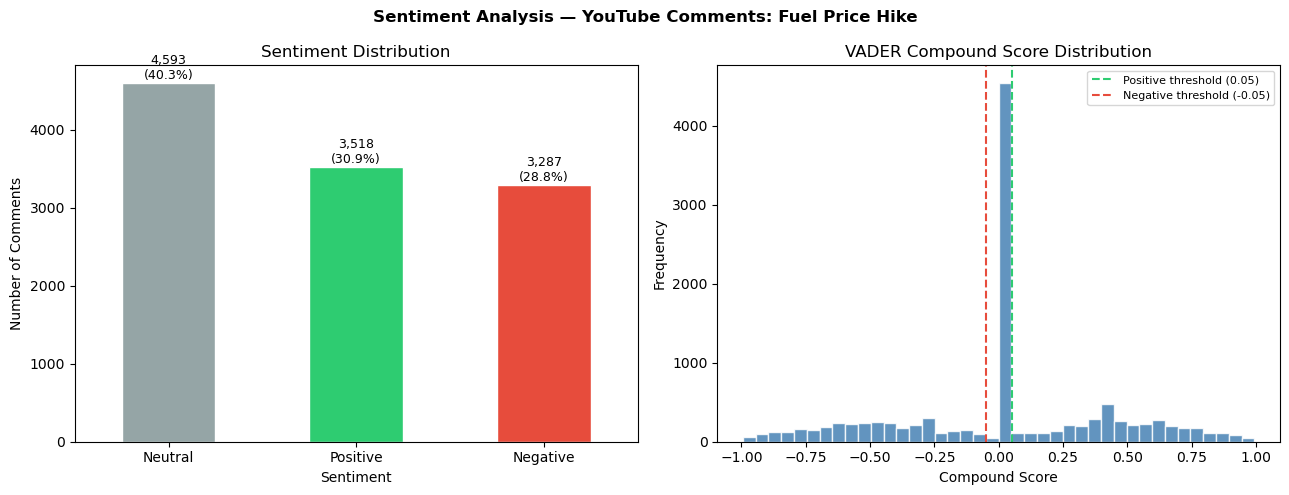

In [33]:
# ── CELL 6: Sentiment Distribution Plot ───────────────────────────────────────
plot_sentiment_distribution(
    comments_df,
    label_col='label',
    compound_col='compound',
    save_path=os.path.join(OUTPUT_DIR, '05_sentiment_distribution.png')
)




Months in dataset: 41
year_month
2023-01      21
2023-02      47
2023-03       1
2023-04       9
2023-05      93
2023-06      40
2023-07      49
2023-08      14
2023-09     248
2023-10      46
2023-11      36
2023-12      94
2024-01      53
2024-02      25
2024-03      14
2024-04      13
2024-05      20
2024-06      99
2024-07      83
2024-08      29
2024-09      51
2024-10      30
2024-11       9
2024-12      13
2025-01      15
2025-02      25
2025-03      26
2025-04      33
2025-05      40
2025-06      41
2025-07      39
2025-08      63
2025-09     114
2025-10      38
2025-11      38
2025-12      44
2026-01      44
2026-02      59
2026-03    4336
2026-04    1334
2026-05    3972
Name: count, dtype: int64


17:41:37 [INFO] Saved: C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\outputs\06_sentiment_over_time.png


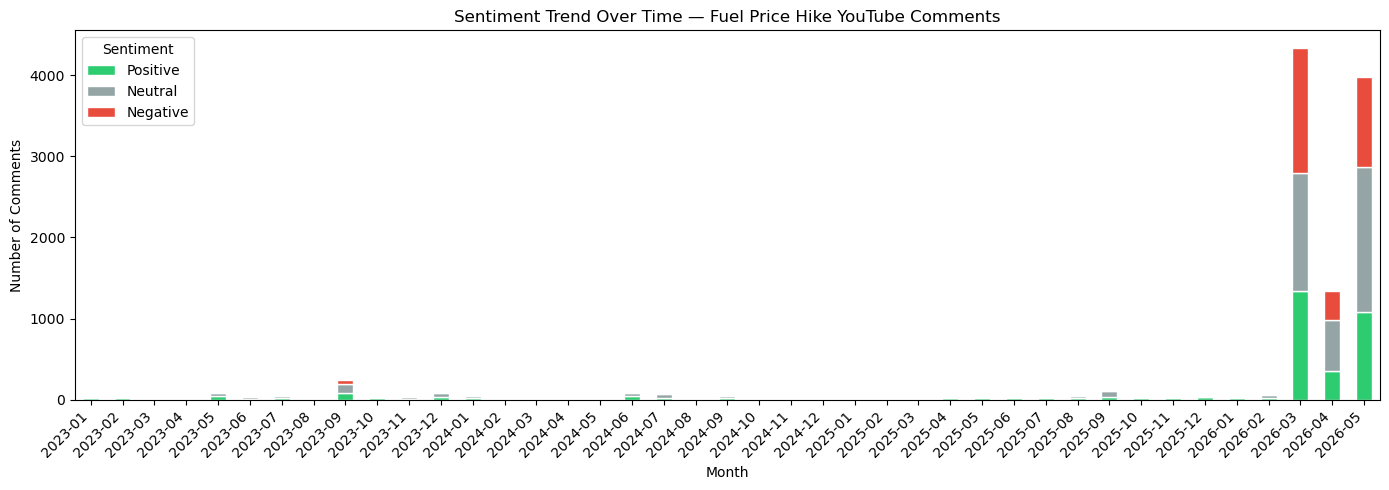

In [34]:
# ── CELL 7: Sentiment Over Time ───────────────────────────────────────────────
# Parse published_at and create year_month column
if 'published_at' in comments_df.columns:
    comments_df['published_at'] = pd.to_datetime(
        comments_df['published_at'], utc=True, errors='coerce'
    )
    comments_df['year_month'] = (comments_df['published_at']
                                  .dt.to_period('M')
                                  .astype(str))

    # Only plot if we have multiple months
    n_months = comments_df['year_month'].nunique()
    print(f"\nMonths in dataset: {n_months}")
    print(comments_df['year_month'].value_counts().sort_index())

    if n_months > 1:
        plot_sentiment_over_time(
            comments_df,
            time_col='year_month',
            label_col='label',
            save_path=os.path.join(OUTPUT_DIR, '06_sentiment_over_time.png')
        )
    else:
        print("⚠️  Only one month in data — skipping time trend plot.")
else:
    print("⚠️  No 'published_at' column found — skipping time trend plot.")



In [35]:
# ── CELL 8: Sentiment by Video ────────────────────────────────────────────────
# Which videos attracted the most negative reactions?
if 'video_id' in comments_df.columns:
    video_sentiment = (comments_df.groupby(['video_id', 'label'])
                       .size().unstack(fill_value=0))

    # Add video titles if available
    if 'title' in videos_df.columns:
        video_sentiment = video_sentiment.merge(
            videos_df[['video_id', 'title']].drop_duplicates(),
            on='video_id', how='left'
        )

    # Sort by negative comment count
    if 'Negative' in video_sentiment.columns:
        video_sentiment = video_sentiment.sort_values('Negative', ascending=False)
        print("\nTop 10 videos by negative comment count:")
        cols = ['title', 'Positive', 'Neutral', 'Negative'] \
               if 'title' in video_sentiment.columns \
               else ['video_id', 'Positive', 'Neutral', 'Negative']
        print(video_sentiment[cols].head(10).to_string(index=False))




Top 10 videos by negative comment count:
                                                                                             title  Positive  Neutral  Negative
            Spike in alleged fuel thefts as petrol prices continue to skyrocket | 9 News Australia        23       22        72
                    &#39;Vibes are bad&#39;: Ongoing Iran war adds to Americans&#39; economic woes        47       31        67
         President Donald Trump talks gas, gas prices: &#39;There&#39;s so much oil out there&#39;        31       42        64
“We’re spending billions to have prices go up”: Americans react to rising gas prices amid Iran war        40       44        64
                                      Rubio addresses concerns about high gas prices amid Iran war        44       38        63
                                                        $200 Oil. The World Economy is OBLITERATED        51       36        62
             &#39;Steady climb downward&#39;: Enten unpacks Tr

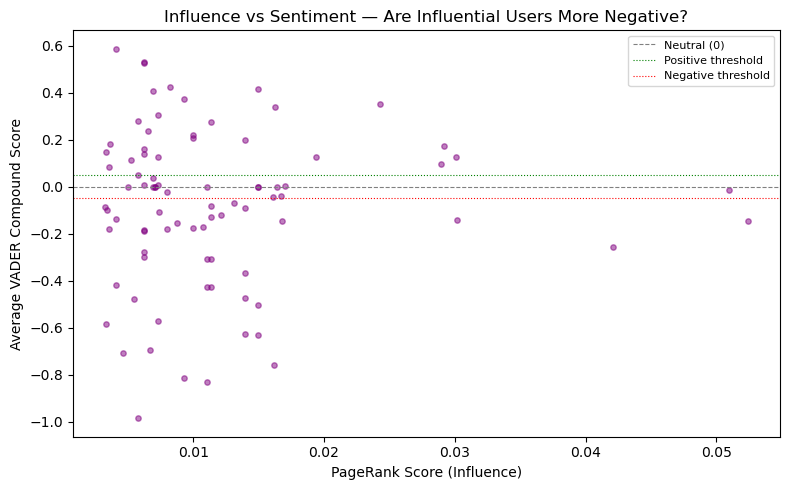


Correlation: PageRank vs Avg Sentiment = 0.0142


In [36]:
# ── CELL 9: Load network metrics & link sentiment to influence ─────────────────
network_metrics_path = os.path.join(DATA_DIR, 'network_metrics.csv')
if os.path.exists(network_metrics_path):
    metrics_df = pd.read_csv(network_metrics_path)

    # Average sentiment per user
    user_sentiment = (comments_df.groupby('author_id')['compound']
                      .agg(['mean', 'count'])
                      .reset_index()
                      .rename(columns={'mean': 'avg_sentiment', 'count': 'n_comments'}))

    merged_metrics = metrics_df.merge(
        user_sentiment,
        left_on='node', right_on='author_id', how='left'
    )

    # Influential users tend to be more negative/positive?
    plt.figure(figsize=(8, 5))
    plt.scatter(
        merged_metrics['pagerank'],
        merged_metrics['avg_sentiment'],
        alpha=0.5, s=15, color='purple'
    )
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Neutral (0)')
    plt.axhline(0.05, color='green', linestyle=':', linewidth=0.8, label='Positive threshold')
    plt.axhline(-0.05, color='red', linestyle=':', linewidth=0.8, label='Negative threshold')
    plt.xlabel("PageRank Score (Influence)")
    plt.ylabel("Average VADER Compound Score")
    plt.title("Influence vs Sentiment — Are Influential Users More Negative?")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '07_influence_vs_sentiment.png'), dpi=150)
    plt.show()

    print("\nCorrelation: PageRank vs Avg Sentiment =",
          round(merged_metrics[['pagerank', 'avg_sentiment']].dropna().corr()
                .iloc[0, 1], 4))
else:
    print("⚠️  network_metrics.csv not found — run Notebook 03 first.")



In [37]:
# ── CELL 10: TF-IDF Top Terms ─────────────────────────────────────────────────
# Identify the most discriminating terms per sentiment class
# before topic modelling — gives quick insight into vocabulary

tfidf_results = tfidf_by_sentiment(
    comments_df,
    text_col='text_clean',
    label_col='label',
    top_n=15,
)

for label, df in tfidf_results.items():
    print(f"\nTop 15 TF-IDF terms — {label} comments:")
    print(df.to_string(index=False))




Top 15 TF-IDF terms — Positive comments:
      term  tfidf_mean
     trump    0.022232
      love    0.018675
     thank    0.017030
    thanks    0.015398
     great    0.014888
       car    0.014676
    better    0.011328
      time    0.010527
       lol    0.010127
government    0.010008
    diesel    0.009839
      want    0.009390
     years    0.009355
      best    0.009292
   america    0.008963

Top 15 TF-IDF terms — Negative comments:
      term  tfidf_mean
     trump    0.028585
       war    0.027944
government    0.015806
      iran    0.015313
      stop    0.013883
   country    0.011096
     world    0.010953
       bad    0.010068
     money    0.009965
   america    0.009316
      high    0.009253
       car    0.009073
      time    0.009062
     years    0.008618
     never    0.008525

Top 15 TF-IDF terms — Neutral comments:
      term  tfidf_mean
       hai    0.023560
     trump    0.016452
    diesel    0.014166
       car    0.008855
     india    0.008337
 

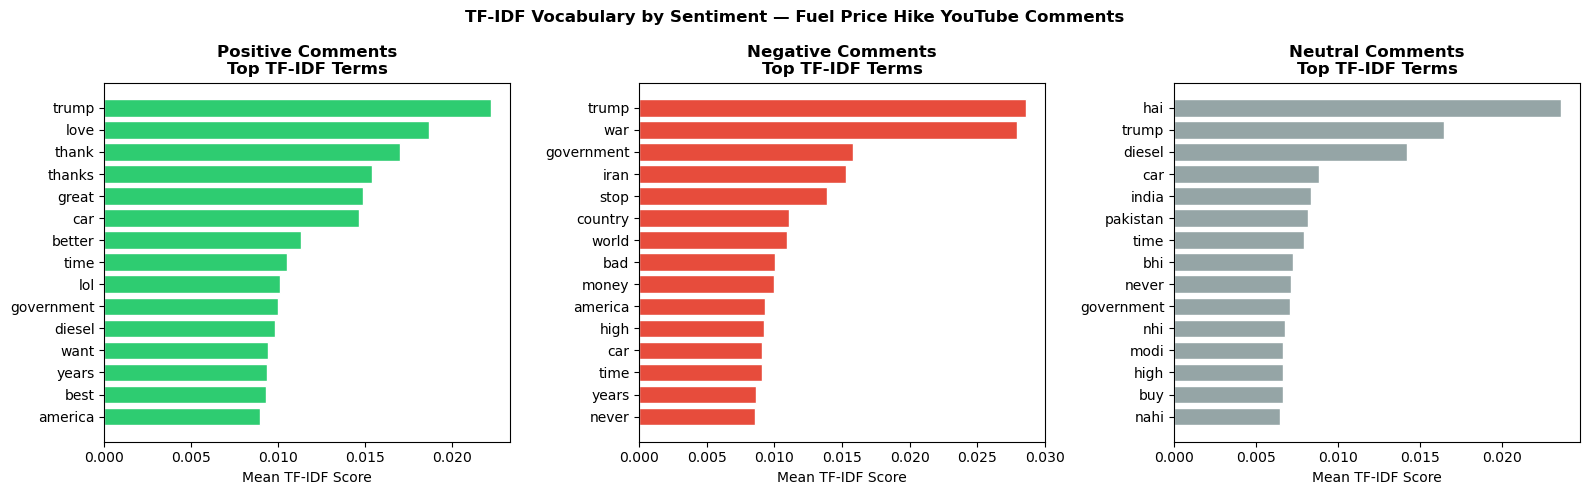

In [38]:
# ── CELL 11: TF-IDF Bar Chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}

for ax, (label, df) in zip(axes, tfidf_results.items()):
    ax.barh(df['term'], df['tfidf_mean'],
            color=colors.get(label, 'steelblue'), edgecolor='white')
    ax.set_title(f"{label} Comments\nTop TF-IDF Terms", fontweight='bold')
    ax.set_xlabel("Mean TF-IDF Score")
    ax.invert_yaxis()

plt.suptitle("TF-IDF Vocabulary by Sentiment — Fuel Price Hike YouTube Comments",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '08_tfidf_by_sentiment.png'), dpi=150,
            bbox_inches='tight')
plt.show()



Finding optimal number of topics (this may take 2-3 minutes)...


17:42:09 [INFO]   k=3: perplexity=1117.78, log_likelihood=-493948.33
17:42:35 [INFO]   k=4: perplexity=1113.33, log_likelihood=-493667.34
17:43:02 [INFO]   k=5: perplexity=1142.10, log_likelihood=-495462.91
17:43:28 [INFO]   k=6: perplexity=1167.17, log_likelihood=-496990.59
17:43:53 [INFO]   k=7: perplexity=1188.60, log_likelihood=-498271.28
17:44:18 [INFO]   k=8: perplexity=1227.55, log_likelihood=-500540.19
17:44:43 [INFO]   k=9: perplexity=1235.92, log_likelihood=-501018.44
17:45:08 [INFO]   k=10: perplexity=1277.59, log_likelihood=-503352.02
17:45:08 [INFO] 
Lowest perplexity at k=4 (perplexity=1113.33)



Perplexity results:
 num_topics  perplexity  log_likelihood
          3     1117.78      -493948.33
          4     1113.33      -493667.34
          5     1142.10      -495462.91
          6     1167.17      -496990.59
          7     1188.60      -498271.28
          8     1227.55      -500540.19
          9     1235.92      -501018.44
         10     1277.59      -503352.02


17:45:09 [INFO] Saved: C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\outputs\09_topic_perplexity.png


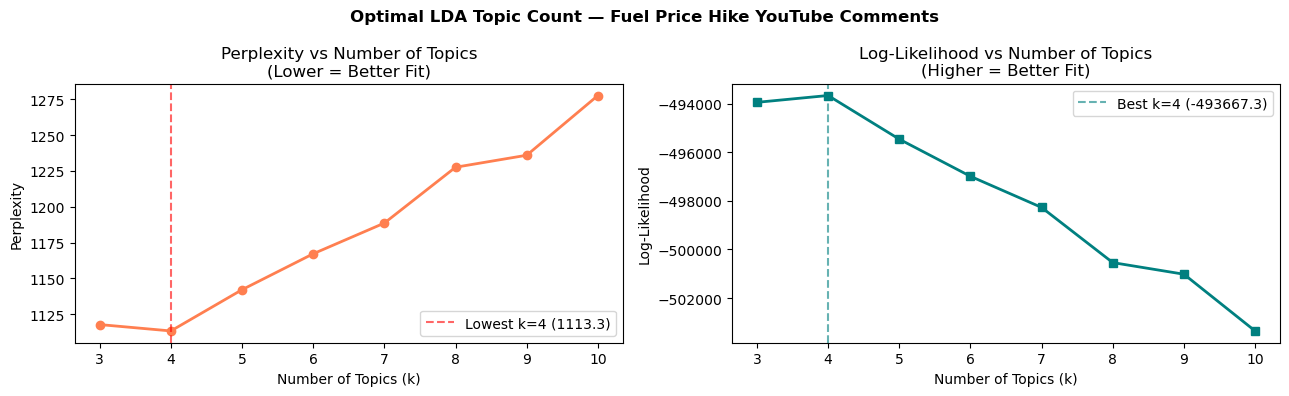

In [39]:
# ============================================================
# SECTION B — TOPIC MODELLING (sklearn LDA)
# ============================================================

# ── CELL 12: Find Optimal Number of Topics ────────────────────────────────────
# Train LDA for k=3..10, compare perplexity (lower = better fit)
# This justifies your chosen k in the report

print("Finding optimal number of topics (this may take 2-3 minutes)...")
texts_for_lda = comments_df['text_clean'].dropna().tolist()

coherence_df = find_optimal_num_topics(
    texts_for_lda,
    topic_range=range(3, 11),
    max_iter=15,
)
print("\nPerplexity results:")
print(coherence_df.to_string(index=False))

plot_topic_perplexity(
    coherence_df,
    save_path=os.path.join(OUTPUT_DIR, '09_topic_perplexity.png')
)



17:45:09 [INFO] Cleaning 11398 documents...



Training final LDA model with k=6 topics...


17:45:11 [INFO] Vocabulary size: 2000 terms
17:45:11 [INFO] Training LDA: 6 topics, 30 iterations...
17:45:33 [INFO] Training complete. Perplexity: 1164.71 (lower = better fit)


✅ LDA trained. Vocabulary size: 2000
   Perplexity: 1164.71

=== LDA Topics — Top 10 Words Each ===
  Topic 0: hai, bhi, nahi, aur, modi, bhai, election, nhi, sab, hain
  Topic 1: country, company, state, market, supply, high, australia, usa, increase, war
  Topic 2: trump, war, iran, american, america, world, president, never, time, vote
  Topic 3: car, year, drive, battery, diesel, mile, buy, vehicle, electric, love
  Topic 4: government, day, nuclear, week, tax, dollar, power, month, already, plant
  Topic 5: pakistan, india, thank, great, thanks, video, biden, lol, please, allah


17:45:35 [INFO] Saved: C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\outputs\10_topic_top_words.png


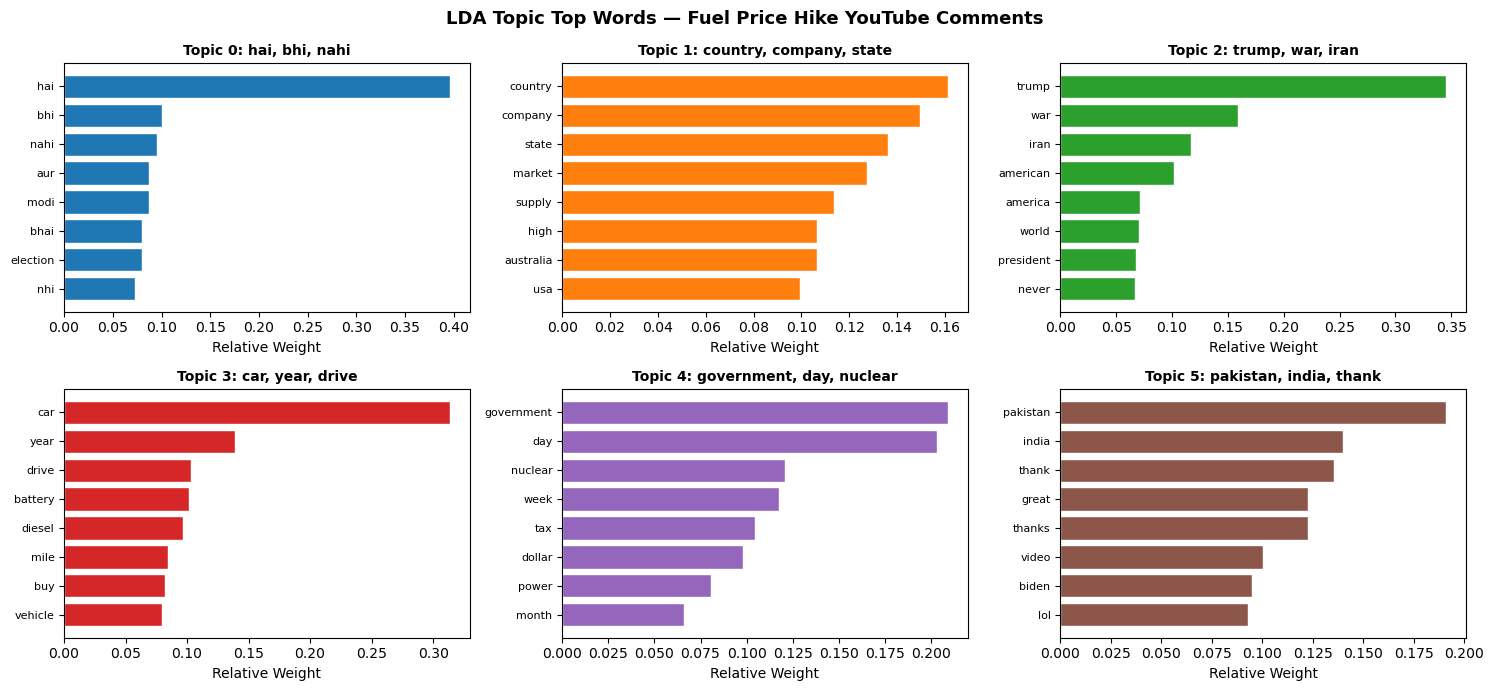

In [40]:
# ── CELL 13: Choose k and Train Final LDA ─────────────────────────────────────
# Pick k at the elbow of the perplexity curve
# Default: 6 topics — change after reviewing plot above

NUM_TOPICS = 6  # ← adjust based on perplexity plot elbow

print(f"\nTraining final LDA model with k={NUM_TOPICS} topics...")
lda_model, dtm, vectorizer, cleaned_texts = build_lda_model(
    texts_for_lda,
    num_topics=NUM_TOPICS,
    max_iter=30,
    max_features=2000,
    min_df=5,
    max_df=0.6,
    random_state=42,
)
print(f"✅ LDA trained. Vocabulary size: {len(vectorizer.get_feature_names_out())}")
print(f"   Perplexity: {lda_model.perplexity(dtm):.2f}")

# ── CELL 14: Inspect Topics ───────────────────────────────────────────────────
topic_labels = get_topic_labels(lda_model, vectorizer, num_words=10)

print("\n=== LDA Topics — Top 10 Words Each ===")
for tid, words in topic_labels.items():
    print(f"  Topic {tid}: {', '.join(words)}")


plot_topic_top_words(
    lda_model, vectorizer,
    num_words=8,
    save_path=os.path.join(OUTPUT_DIR, '10_topic_top_words.png')
)



17:45:37 [INFO] Saved: C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\outputs\11_topic_wordclouds.png


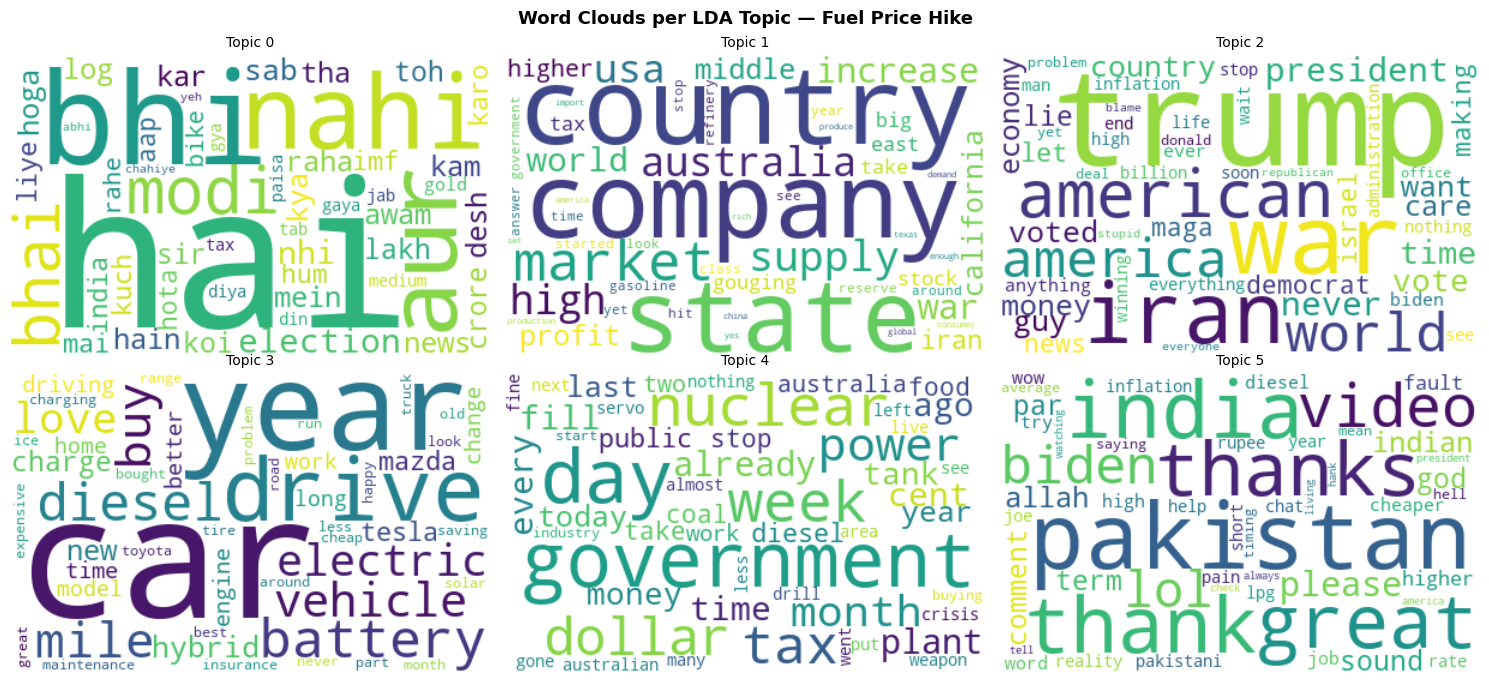


Topic distribution across comments:
  Topic 0 [hai, bhi, nahi]: 2116 comments (18.6%)
  Topic 1 [country, company, state]: 1667 comments (14.6%)
  Topic 2 [trump, war, iran]: 2859 comments (25.1%)
  Topic 3 [car, year, drive]: 1919 comments (16.8%)
  Topic 4 [government, day, nuclear]: 1809 comments (15.9%)
  Topic 5 [pakistan, india, thank]: 1028 comments (9.0%)


In [41]:
# ── CELL 15: Word Clouds per Topic ────────────────────────────────────────────
plot_wordcloud_per_topic(
    lda_model, vectorizer,
    save_path=os.path.join(OUTPUT_DIR, '11_topic_wordclouds.png')
)


comments_df = assign_topics_to_df(
    comments_df, lda_model, dtm, vectorizer,
    topic_labels=topic_labels
)

print("\nTopic distribution across comments:")
topic_dist = comments_df['topic_id'].value_counts().sort_index()
for tid, count in topic_dist.items():
    pct   = count / len(comments_df) * 100
    words = ', '.join(topic_labels.get(tid, [])[:3])
    print(f"  Topic {tid} [{words}]: {count} comments ({pct:.1f}%)")



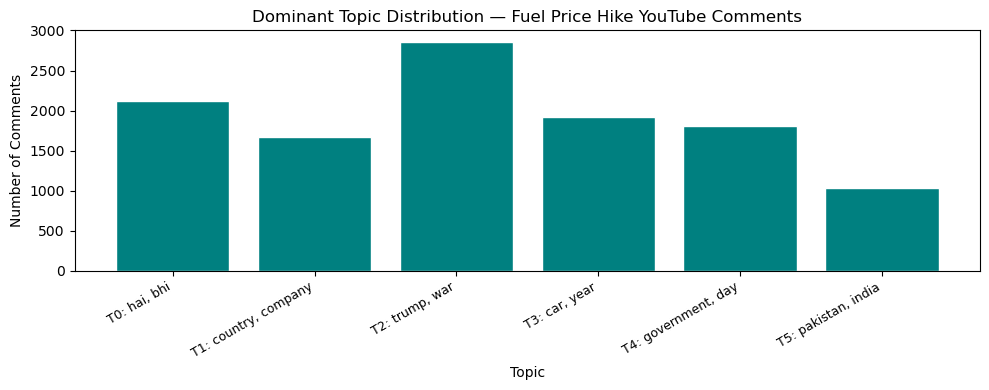

In [42]:
# ── CELL 16: Topic Distribution Bar Chart ─────────────────────────────────────
topic_dist_plot = comments_df['topic_id'].value_counts().sort_index()
labels = [f"T{i}: {', '.join(topic_labels.get(i,[])[:2])}"
          for i in topic_dist_plot.index]

plt.figure(figsize=(10, 4))
plt.bar(labels, topic_dist_plot.values, color='teal', edgecolor='white')
plt.title("Dominant Topic Distribution — Fuel Price Hike YouTube Comments")
plt.xlabel("Topic")
plt.ylabel("Number of Comments")
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '12_topic_distribution.png'), dpi=150)
plt.show()



17:45:38 [INFO] Saved: C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\outputs\13_topic_sentiment_heatmap.png


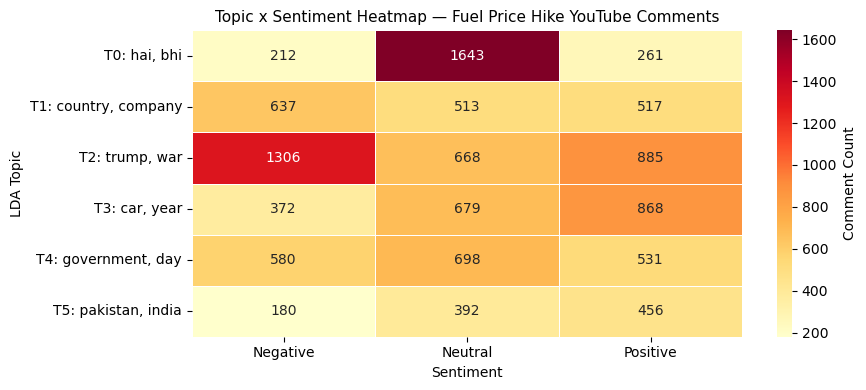


✅ Saved enriched comments to: C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\Data\comments_with_sentiment_topics.csv
   Columns: ['comment_id', 'video_id', 'author_id', 'author_name', 'text', 'like_count', 'reply_count', 'published_at', 'updated_at', 'year_month', 'day_of_week', 'hour', 'is_english', 'text_clean', 'compound', 'label', 'pos', 'neg', 'neu', 'topic_id', 'prob', 'topic_label']
   Shape  : (11398, 22)


In [43]:
# ── CELL 17: Topic × Sentiment Heatmap ───────────────────────────────────────
# Key analysis: which topics generate the most negative reactions?
plot_topic_sentiment_heatmap(
    comments_df,
    topic_col='topic_id',
    label_col='label',
    topic_labels=topic_labels,
    save_path=os.path.join(OUTPUT_DIR, '13_topic_sentiment_heatmap.png')
)

# ── CELL 18: Save Enriched DataFrame ─────────────────────────────────────────
output_path = os.path.join(DATA_DIR, 'comments_with_sentiment_topics.csv')
comments_df.to_csv(output_path, index=False)
print(f"\n✅ Saved enriched comments to: {output_path}")
print(f"   Columns: {comments_df.columns.tolist()}")
print(f"   Shape  : {comments_df.shape}")